# Hands-On: Utilizing Vector Similarity Models

This notebook will walk you through how to:

- Convert text into vectors using pre-trained word embeddings
- Calculate similarity using **cosine similarity** and **Euclidean distance**
- Apply vector similarity in a mini **semantic search** task


##  Step 1: Install Required Libraries


In [1]:
# 🛠️ Step 1: Install sentence-transformers
!pip install -q sentence-transformers

## Step 2: Define Sample Sentences

We’ll use a few example sentences to test vector similarity.

In [2]:
sentences = [
    "I love playing football",
    "Football is a great sport",
    "I enjoy reading books",
    "Books are full of knowledge"
]

## Step 3: Load Pretrained Sentence Transformer

We'll use `all-MiniLM-L6-v2`, a small and fast model that performs well for sentence embeddings.

Model Documentation: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Step 4: Convert Sentences into Vectors

In [4]:
sentence_embeddings = model.encode(sentences)

In [5]:
sentence_embeddings

array([[ 0.00526181, -0.02797893, -0.00119585, ...,  0.05620422,
         0.03577669, -0.06146692],
       [ 0.02437179,  0.03230736,  0.01805485, ...,  0.03563687,
         0.06051832,  0.01362409],
       [ 0.04062897, -0.05146696, -0.03423119, ..., -0.01421372,
        -0.0448189 , -0.04314301],
       [ 0.06517617,  0.00966415, -0.01803675, ..., -0.06184006,
        -0.0381446 ,  0.05026169]], dtype=float32)

## Step 5: Define Cosine Similarity and Euclidean Distance


In [6]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean

def compare_vectors(vec1, vec2):
    cos_sim = cosine_similarity([vec1], [vec2])[0][0]
    euc_dist = euclidean(vec1, vec2)
    return cos_sim, euc_dist

## Step 6: Compare Two Sentences


In [7]:
i = 0  # "I love playing football"
j = 1  # "Football is a great sport"

cos_sim, euc_dist = compare_vectors(sentence_embeddings[i], sentence_embeddings[j])

print(f"Sentence 1: {sentences[i]}")
print(f"Sentence 2: {sentences[j]}")
print(f"\nCosine Similarity: {cos_sim:.4f}")
print(f"Euclidean Distance: {euc_dist:.4f}")

Sentence 1: I love playing football
Sentence 2: Football is a great sport

Cosine Similarity: 0.7419
Euclidean Distance: 0.7185


We can see that the similarity of above sentences is high

In [8]:
i = 0  # "I love playing football"
j = 2  # "I enjoy reading books"

cos_sim, euc_dist = compare_vectors(sentence_embeddings[i], sentence_embeddings[j])

print(f"Sentence 1: {sentences[i]}")
print(f"Sentence 2: {sentences[j]}")
print(f"\nCosine Similarity: {cos_sim:.4f}")
print(f"Euclidean Distance: {euc_dist:.4f}")

Sentence 1: I love playing football
Sentence 2: I enjoy reading books

Cosine Similarity: 0.4059
Euclidean Distance: 1.0901


We can see that the similarity of above sentences is lower

In [9]:
i = 0  # "I love playing football"
j = 3  # "Books are full of knowledge"

cos_sim, euc_dist = compare_vectors(sentence_embeddings[i], sentence_embeddings[j])

print(f"Sentence 1: {sentences[i]}")
print(f"Sentence 2: {sentences[j]}")
print(f"\nCosine Similarity: {cos_sim:.4f}")
print(f"Euclidean Distance: {euc_dist:.4f}")

Sentence 1: I love playing football
Sentence 2: Books are full of knowledge

Cosine Similarity: 0.0673
Euclidean Distance: 1.3658


We can see that the similarity of above sentences is really low

In [10]:
i = 2  # "I enjoy reading books"
j = 3  # "Books are full of knowledge"

cos_sim, euc_dist = compare_vectors(sentence_embeddings[i], sentence_embeddings[j])

print(f"Sentence 1: {sentences[i]}")
print(f"Sentence 2: {sentences[j]}")
print(f"\nCosine Similarity: {cos_sim:.4f}")
print(f"Euclidean Distance: {euc_dist:.4f}")

Sentence 1: I enjoy reading books
Sentence 2: Books are full of knowledge

Cosine Similarity: 0.5607
Euclidean Distance: 0.9374


We can see that the similarity of above is relatively high

## Step 7: Semantic Search Example

We’ll input a query and retrieve the most similar sentences based on cosine similarity.

In [13]:
query = "I like soccer"
query_vec = model.encode(query)

similarities = cosine_similarity([query_vec], sentence_embeddings)[0]
results = sorted(zip(sentences, similarities), key=lambda x: x[1], reverse=True)

print(f"\nQuery: {query}")
print("\nTop matches:")
for sentence, score in results:
    print(f"{score:.4f} - {sentence}")


Query: I like soccer

Top matches:
0.6726 - I love playing football
0.6474 - Football is a great sport
0.3763 - I enjoy reading books
0.0496 - Books are full of knowledge


## Summary

- You used a modern sentence embedding model (`all-MiniLM-L6-v2`) to vectorize text
- Compared sentences with **cosine similarity** and **Euclidean distance**
- Built a mini **semantic search engine** in a few lines!

Try using your own sentences to explore!


# Hands-On: Book Recommendation — Content-Based & Collaborative Filtering

In [14]:
!pip install -q sentence-transformers
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

##  Step 1: Sample Book Data

In [15]:
books = [
    "Harry Potter and the Sorcerer's Stone",
    "The Hobbit by J.R.R. Tolkien",
    "A Game of Thrones",
    "The Da Vinci Code",
    "Introduction to Machine Learning",
    "Deep Learning with Python",
    "The Art of Computer Programming",
    "Twilight: A Love Story",
    "The Hunger Games",
    "The Catcher in the Rye"
]

## Content-Based Filtering

### Step 2.1: Encode Book Titles

In [16]:
model = SentenceTransformer('all-MiniLM-L6-v2')
book_vectors = model.encode(books)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
book_vectors

array([[-0.04757997,  0.02530961, -0.05523194, ...,  0.0101803 ,
         0.00082864,  0.03808168],
       [-0.0626367 ,  0.0739744 , -0.06714463, ...,  0.01334876,
        -0.0359011 ,  0.03419316],
       [-0.08192022,  0.0820677 , -0.03460618, ..., -0.03655898,
        -0.03281705,  0.05273609],
       ...,
       [-0.03298087,  0.03081851,  0.04389296, ..., -0.05083399,
         0.00904867,  0.01391229],
       [-0.02185878,  0.04757687, -0.03854696, ...,  0.02066132,
        -0.06541342,  0.03881576],
       [-0.00543338, -0.00491425, -0.04160978, ..., -0.00036805,
         0.04832122,  0.07436879]], dtype=float32)

### Step 2.2: Define Recommender

In [20]:
def content_based_recommender(query, top_n=5):
    query_vec = model.encode([query])
    similarities = cosine_similarity(query_vec, book_vectors)[0]
    top_indices = similarities.argsort()[::-1][:top_n]

    print(f"\n📖 Query: {query}")
    print("📚 Top Content-Based Recommendations:\n")
    for idx in top_indices:
        print(f"{similarities[idx]:.4f} - {books[idx]}")

### Step 2.3: Run Example

In [21]:
content_based_recommender("A fantasy novel with magic and dragons")


📖 Query: A fantasy novel with magic and dragons
📚 Top Content-Based Recommendations:

0.4881 - A Game of Thrones
0.4130 - Harry Potter and the Sorcerer's Stone
0.3934 - The Hobbit by J.R.R. Tolkien
0.2848 - The Da Vinci Code
0.2762 - Twilight: A Love Story


The reason **"A Game of Thrones"** appears at the top of the recommendations is because, according to the sentence embedding model (`all-MiniLM-L6-v2`), its title is the most semantically similar to the query **"A fantasy novel with magic and dragons."** The number shown (e.g., **0.4881**) is the cosine similarity score between the query and each book title: a value closer to 1 would mean they are very similar in meaning, while lower values indicate weaker similarity.

In this case, the scores aren’t close to 1 because we’re only using short **book titles** as features, without richer context like plot summaries or keywords — so the model makes the best match it can based on limited text, still correctly identifying titles known for dragons and magic, like *Game of Thrones*, *Harry Potter*, and *The Hobbit*.


## Collaborative Filtering (User-Based)

### Step 3.1: Simulate User Ratings Matrix

In [23]:
# Users: rows, Books: columns
ratings_dict = {
    'User1': [5, 5, 4, 0, 0, 0, 0, 2, 0, 0],  # Likes fantasy
    'User2': [0, 0, 0, 5, 4, 5, 4, 0, 0, 0],  # Likes tech/thrillers, hasn't seen Catcher or Hunger Games
    'User3': [5, 4, 5, 0, 0, 0, 0, 0, 4, 1],  # Similar to User1, but watched Hunger Games + Catcher
    'User4': [0, 0, 1, 4, 5, 4, 5, 4, 0, 0],  # Similar to User2, has also watched Twilight
}


ratings_df = pd.DataFrame(ratings_dict, index=books).T
ratings_df

,Harry Potter and the Sorcerer's Stone,The Hobbit by J.R.R. Tolkien,A Game of Thrones,The Da Vinci Code,Introduction to Machine Learning,Deep Learning with Python,The Art of Computer Programming,Twilight: A Love Story,The Hunger Games,The Catcher in the Rye
User1,5,5,4,0,0,0,0,2,0,0
User2,0,0,0,5,4,5,4,0,0,0
User3,5,4,5,0,0,0,0,0,4,1
User4,0,0,1,4,5,4,5,4,0,0


### Step 3.2: Compute User Similarity Matrix

In [25]:
user_sim = cosine_similarity(ratings_df)
user_sim_df = pd.DataFrame(user_sim, index=ratings_df.index, columns=ratings_df.index)
user_sim_df

,User1,User2,User3,User4
User1,1.000000,0.000000,0.852757,0.144150
User2,0.000000,1.000000,0.000000,0.887903
User3,0.852757,0.000000,1.000000,0.055159
User4,0.144150,0.887903,0.055159,1.000000


### Step 3.3: Recommend for a User

In [26]:
def collaborative_recommend(user_id, ratings_df, top_n=3, min_score=3):
    from sklearn.metrics.pairwise import cosine_similarity
    import numpy as np

    # Step 1: Compute cosine similarity between users
    user_sim = cosine_similarity(ratings_df)
    user_sim_df = pd.DataFrame(user_sim, index=ratings_df.index, columns=ratings_df.index)

    # Step 2: Get similarity scores for the target user (excluding self)
    sim_scores = user_sim_df[user_id].drop(user_id)

    # Step 3: Predict ratings for unseen books
    weighted_scores = np.dot(sim_scores.values, ratings_df.drop(user_id).values)
    sum_sim = sim_scores.sum()

    if sum_sim == 0:
        print(f"⚠️ Not enough similar users to recommend for {user_id}.")
        return

    predicted_ratings = weighted_scores / sum_sim

    # Step 4: Filter out already-rated books
    user_ratings = ratings_df.loc[user_id].values
    unrated_indices = np.where(user_ratings == 0)[0]

    # Step 5: Filter by minimum predicted score
    qualified_indices = [i for i in unrated_indices if predicted_ratings[i] >= min_score]

    if not qualified_indices:
        print(f"😕 No high-quality recommendations for {user_id}.")
        return

    # Step 6: Sort and get top-N
    sorted_indices = sorted(qualified_indices, key=lambda i: predicted_ratings[i], reverse=True)
    top_indices = sorted_indices[:top_n]
    recommended_books = ratings_df.columns[top_indices]
    recommended_scores = predicted_ratings[top_indices]

    # Step 7: Display results
    print(f"📚 High-Quality Collaborative Recommendations for {user_id} (score ≥ {min_score}):\n")
    for book, score in zip(recommended_books, recommended_scores):
        print(f"{score:.2f} - {book}")

### Step 3.4: Try Collaborative Recommendation

In [29]:
collaborative_recommend('User1', ratings_df)

📚 High-Quality Collaborative Recommendations for User1 (score ≥ 3):

3.42 - The Hunger Games


In [30]:
collaborative_recommend('User2', ratings_df)

📚 High-Quality Collaborative Recommendations for User2 (score ≥ 3):

4.00 - Twilight: A Love Story


## Summary
Content-Based: “You like items similar to the ones you liked before.”

Collaborative Filtering: “People who are similar to you like similar things.”


## Insights

| User Pair     | Similarity | Overlap       | New Recommendations   |
| ------------- | ---------- | ------------- | --------------------- |
| **User1 & 3** | High       | Fantasy books | Hunger Games, Catcher |
| **User2 & 4** | High       | Tech books    | Twilight              |


# Hands-On: Clustering Based on Vector Similarity

In this hands-on, we'll use K-Means clustering to group similar books together based on their vector representations. Clustering helps us discover hidden groupings or themes in data, especially in recommendation systems and search engines.

We'll simulate simple book embeddings and cluster them using cosine similarity.


## Step 1: Import Required Libraries

In [31]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load MiniLM model
model = SentenceTransformer('all-MiniLM-L6-v2')

'The read operation timed out' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 2s [Retry 2/5].


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Step 2: Generate Sentence Embeddings

Each book title is encoded into a dense 384-dimensional vector that captures its semantic meaning.


In [32]:
books = [
    {
        "title": "Harry Potter",
        "description": "A young wizard attends a magical school and battles a dark lord.",
        "genre": "Fantasy"
    },
    {
        "title": "Lord of the Rings",
        "description": "A hobbit carries a powerful ring to Mount Doom to destroy it.",
        "genre": "Fantasy"
    },
    {
        "title": "The Hobbit",
        "description": "A small hobbit goes on an adventure with dwarves to reclaim treasure.",
        "genre": "Fantasy"
    },
    {
        "title": "Python Basics",
        "description": "An introductory book to programming with Python.",
        "genre": "Education"
    },
    {
        "title": "Deep Learning",
        "description": "A detailed guide on deep learning concepts and neural networks.",
        "genre": "Education"
    },
    {
        "title": "AI Fundamentals",
        "description": "An overview of artificial intelligence and its applications.",
        "genre": "Education"
    },
    {
        "title": "Sherlock Holmes",
        "description": "A detective solves mysteries using logic and observation.",
        "genre": "Mystery"
    },
    {
        "title": "Hunger Games",
        "description": "A dystopian future where teens fight in a deadly televised competition.",
        "genre": "Sci-Fi"
    }
]

# Combine title, description, and genre into one string
book_texts = [
    f"{book['title']}. {book['description']} Genre: {book['genre']}."
    for book in books
]
titles = [book["title"] for book in books]

In [33]:
embeddings = model.encode(book_texts)
book_df = pd.DataFrame(embeddings, index=titles)
book_df.columns = [f"x{i+1}" for i in range(book_df.shape[1])]

## Step 3: Prepare and Normalize Vectors

We normalize the vectors. Normalization is critical when using cosine similarity or distance-based clustering to ensure fair comparison across all features.


In [37]:
# Normalize vectors
book_matrix = normalize(book_df.values)

## Step 4: Apply KMeans Clustering
We apply KMeans to group similar books into clusters. We’ve chosen 3 clusters, but this can be adjusted depending on the data. The result is a cluster label assigned to each book.


In [38]:
# Cluster the vectors
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(book_matrix)

# Add cluster labels
book_df['cluster'] = clusters

## Step 5: Visualize the Clusters (PCA)

We reduce the 3D vectors to 2D using PCA for easier visualization. The scatter plot shows how books are grouped based on their semantic similarity.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


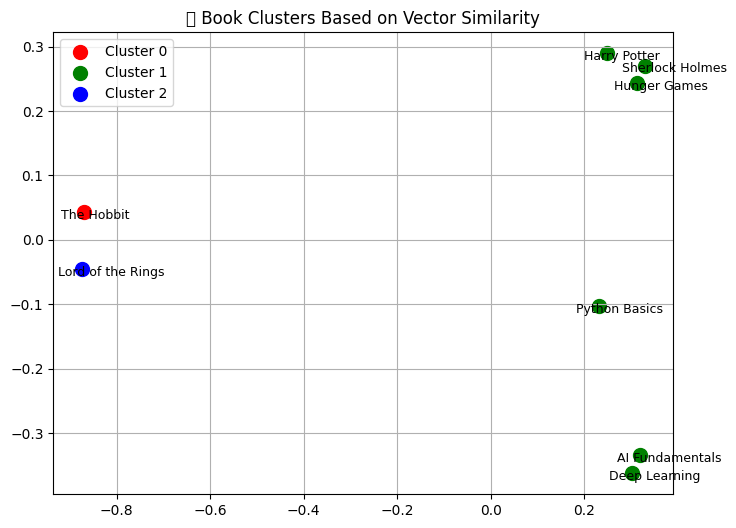

In [39]:
# Reduce to 2D for visualization
pca = PCA(n_components=2)
book_2d = pca.fit_transform(book_matrix)

# Plot
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i in range(n_clusters):
    idx = clusters == i
    plt.scatter(book_2d[idx, 0], book_2d[idx, 1], c=colors[i], label=f'Cluster {i}', s=100)

# Annotate points
for i, name in enumerate(titles):
    plt.annotate(name, (book_2d[i, 0] - 0.05, book_2d[i, 1] - 0.01), fontsize=9)

plt.title("📚 Book Clusters Based on Vector Similarity")
plt.legend()
plt.grid(True)
plt.show()

## Summary

- Books within the same cluster are semantically similar.
- This technique can help:
  - Recommend similar books
  - Organize content automatically
  - Understand hidden structure in text data

Try modifying the book vectors or number of clusters to explore different groupings!


# Other References

Read more here about on how to utilize **all-MiniLM-L6-v2**
1. https://medium.com/@rahultiwari065/unlocking-the-power-of-sentence-embeddings-with-all-minilm-l6-v2-7d6589a5f0aa
2. https://dataloop.ai/library/model/sentence-transformers_all-minilm-l6-v2/

Read more here to consider other models

| Model                                              | Key Points                                                            | Documentation / Model Card                                                                                                    |
|----------------------------------------------------|-----------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------|
| **all-MiniLM-L12-v2**                              | Larger than L6 → better accuracy, still very efficient                | [Hugging Face](https://huggingface.co/sentence-transformers/all-MiniLM-L12-v2)                                                |
| **paraphrase-MiniLM-L6-v2**                        | Optimized for paraphrastic similarity                                 | [Hugging Face](https://huggingface.co/sentence-transformers/paraphrase-MiniLM-L6-v2)                                          |
| **paraphrase-mpnet-base-v2**                       | Larger model, better accuracy, slower than MiniLM                     | [Hugging Face](https://huggingface.co/sentence-transformers/paraphrase-mpnet-base-v2)                                         |
| **all-mpnet-base-v2**                              | Strong general-purpose performance                                    | [Hugging Face](https://huggingface.co/sentence-transformers/all-mpnet-base-v2)                                                |
| **distiluse-base-multilingual-cased-v2**           | Multilingual: supports 50+ languages; lightweight                     | [Hugging Face](https://huggingface.co/sentence-transformers/distiluse-base-multilingual-cased-v2)                             |
| **paraphrase-multilingual-MiniLM-L12-v2**          | Multilingual; good trade-off between speed and quality                | [Hugging Face](https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)                            |
